## 1.2 Teoria de Nyquist e Análise Espectral

Responda formalmente às questões teóricas e práticas abaixo:

1. Enuncie o Teorema de Nyquist-Shannon. Explique o fenômeno de *aliasing* (sobreposição espectral) e quais as consequências de amostrar um sinal abaixo da frequência de Nyquist:

$$
f_s < 2f_{\max}
$$

2. Um sinal de voz possui frequências na faixa de 0 a 4 kHz. Qual deve ser a frequência de amostragem mínima para que ele seja digitalizado sem perda de informação?

3. Considere o sinal analógico

$$
x(t)=\cos(2\pi \cdot 100t)
$$

amostrado a uma taxa de

$$
f_s=150\,\text{Hz}.
$$

a) Qual é a frequência do sinal reconstruído após o filtro passa-baixa ideal?

b) Qual seria a frequência correta e por que ocorre o fenômeno observado?

### Resolução das Questões de Nyquist

**Questão 1**

De acordo com o Teorema de Nyquist-Shannon, um sinal limitado em frequência pode ser recuperado a partir de suas amostras quando a taxa de amostragem é, no mínimo, duas vezes maior que a maior frequência presente no sinal. Assim, considerando $f_{\max}$ como a maior componente de frequência, tem-se:

$$
f_s \geq 2f_{\max}
$$

Quando se utiliza

$$
f_s < 2f_{\max},
$$

as cópias do espectro geradas durante a amostragem passam a se sobrepor. Esse efeito recebe o nome de *aliasing*.

Como consequência, frequências diferentes podem produzir a mesma representação após a amostragem. Dessa maneira, componentes originalmente mais altas podem aparecer como frequências mais baixas, tornando impossível recuperar perfeitamente o espectro original apenas com um filtro passa-baixas.

---

**Questão 2**

Como o sinal de voz possui componentes de frequência entre 0 e 4 kHz:

$$
f_{\max}=4\,\text{kHz}
$$

Aplicando o critério de Nyquist-Shannon:

$$
f_s \geq 2f_{\max}
$$

$$
f_s \geq 2(4\,\text{kHz})
$$

$$
\boxed{f_s \geq 8\,\text{kHz}}
$$

Logo, a frequência mínima teórica de amostragem é:

$$
\boxed{f_s=8\,\text{kHz}}
$$

---

**Questão 3**

O sinal fornecido é:

$$
x(t)=\cos(2\pi\cdot100t)
$$

Comparando com

$$
x(t)=A\cos(2\pi ft+\phi),
$$

obtém-se:

$$
\boxed{f_0=100\,\text{Hz}}
$$

Pelo critério de Nyquist:

$$
f_s\geq2f_0
$$

$$
f_s\geq2(100)=200\,\text{Hz}
$$

Entretanto:

$$
f_s=150\,\text{Hz}
$$

Como

$$
150<200,
$$

ocorre *aliasing*.

A maior frequência que pode ser representada sem ambiguidade é:

$$
\frac{f_s}{2}=\frac{150}{2}=75\,\text{Hz}
$$

A frequência equivalente é:

$$
f_{\text{alias}}=|f_0-f_s|
$$

$$
f_{\text{alias}}=|100-150|=50\,\text{Hz}
$$

Portanto:

$$
\boxed{f_r=50\,\text{Hz}}
$$

A frequência original, entretanto, é:

$$
\boxed{f_0=100\,\text{Hz}}
$$

## 1.3 Funções Fundamentais e Periodicidade

Para as funções discretas Impulso Unitário $\delta[n]$ e Degrau Unitário $u[n]$:

$$
\delta[n] =
\begin{cases}
1, & n = 0 \\
0, & n \neq 0
\end{cases}
$$

e

$$
u[n] =
\begin{cases}
1, & n \geq 0 \\
0, & n < 0
\end{cases}
$$

A relação matemática entre elas é:

$$
\boxed{\delta[n]=u[n]-u[n-1]}
$$

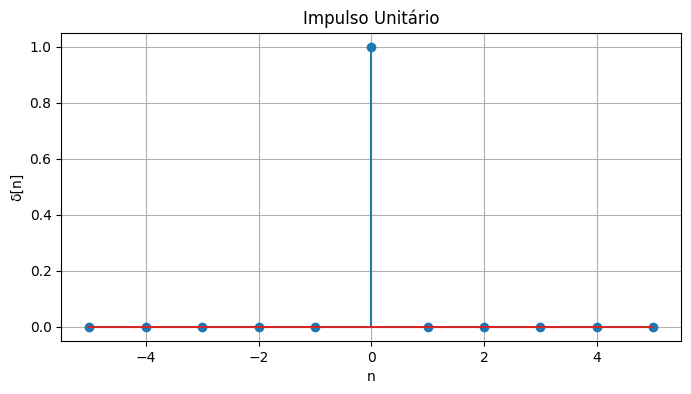

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-5, 6)

# Impulso unitário
delta = np.where(n == 0, 1, 0)

# Degrau unitário
u = np.where(n >= 0, 1, 0)

plt.figure(figsize=(8, 4))
plt.stem(n, delta)

plt.xlabel('n')
plt.ylabel('δ[n]')
plt.title('Impulso Unitário')
plt.grid()

plt.show()

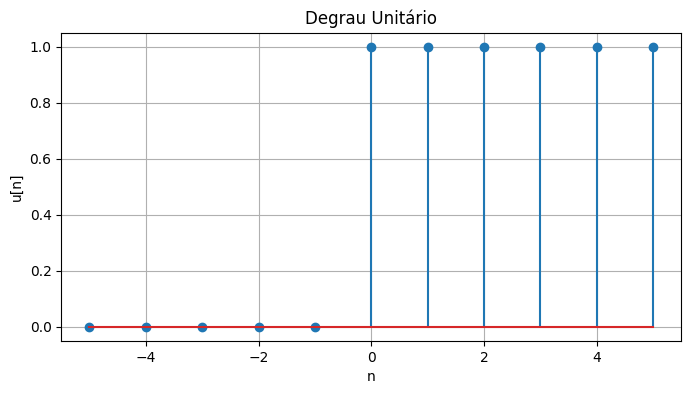

In [3]:
plt.figure(figsize=(8, 4))
plt.stem(n, u)

plt.xlabel('n')
plt.ylabel('u[n]')
plt.title('Degrau Unitário')
plt.grid()

plt.show()

n = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
u[n] = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
u[n-1] = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
u[n] - u[n-1] = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


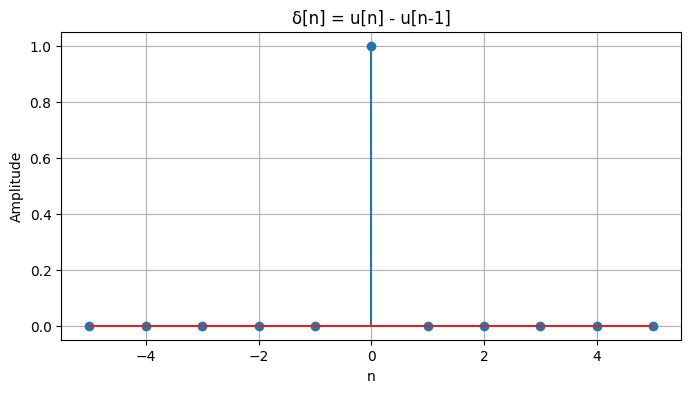

In [4]:
u_n = np.where(n >= 0, 1, 0)
u_n_1 = np.where(n - 1 >= 0, 1, 0)

resultado = u_n - u_n_1

print("n =", n.tolist())
print("u[n] =", u_n.tolist())
print("u[n-1] =", u_n_1.tolist())
print("u[n] - u[n-1] =", resultado.tolist())

plt.figure(figsize=(8, 4))
plt.stem(n, resultado)

plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('δ[n] = u[n] - u[n-1]')
plt.grid()

plt.show()

### Aplicações das funções fundamentais

Para o impulso unitário $\delta[n]$, duas aplicações importantes são:

1. Representação de sinais como soma de impulsos deslocados:

$$
x[n]=
\sum_{k=-\infty}^{\infty}
x[k]\delta[n-k]
$$

2. Caracterização de um SLIT por meio de sua resposta ao impulso $h[n]$.

Conhecendo $h[n]$, é possível determinar a saída do sistema para diferentes entradas.

Para o degrau unitário $u[n]$:

1. Pode-se analisar a resposta ao degrau de um sistema.

2. O degrau pode ser representado como uma soma acumulada de impulsos:

$$
u[n]=
\sum_{k=-\infty}^{n}\delta[k]
$$

e a relação inversa é:

$$
\delta[n]=u[n]-u[n-1]
$$

## 1.4 Análise de Periodicidade Discreta

Um sinal senoidal discreto

$$
x[n]=A\cos(\Omega n+\phi)
$$

é periódico quando existe um número inteiro positivo $N$ tal que:

$$
x[n+N]=x[n]
$$

Assim:

$$
A\cos(\Omega(n+N)+\phi)
=
A\cos(\Omega n+\phi)
$$

Para que o cosseno retorne ao mesmo valor:

$$
\Omega N=2\pi m
$$

em que $m$ é inteiro.

Portanto:

$$
\boxed{
\frac{\Omega}{2\pi}
=
\frac{m}{N}
}
$$

Logo, um sinal senoidal discreto somente é periódico quando $\Omega/(2\pi)$ é um número racional.

### a) Primeiro sinal

$$
x_1[n] = \cos\left(\frac{\pi n}{4}\right)
$$

Tem-se:

$$
\Omega = \frac{\pi}{4}
$$

Logo:

$$
\frac{\Omega}{2\pi}
=
\frac{\frac{\pi}{4}}{2\pi}
=
\frac{1}{8}
$$

Portanto:

$$
m = 1
\qquad
N = 8
$$

Assim, o sinal é periódico e seu período fundamental é:

$$
\boxed{N = 8}
$$

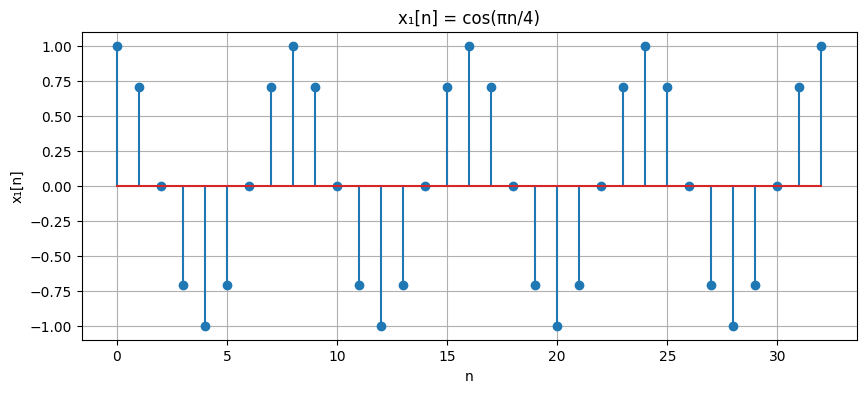

In [5]:
n = np.arange(0, 33)

x1 = np.cos(np.pi * n / 4)

plt.figure(figsize=(10, 4))
plt.stem(n, x1)

plt.xlabel('n')
plt.ylabel('x₁[n]')
plt.title('x₁[n] = cos(πn/4)')
plt.grid()

plt.show()

### b) Segundo sinal

$$
x_2[n] = \cos\left(\frac{3\pi n}{8}\right)
$$

Tem-se:

$$
\Omega = \frac{3\pi}{8}
$$

Então:

$$
\frac{\Omega}{2\pi}
=
\frac{\frac{3\pi}{8}}{2\pi}
=
\frac{3}{16}
$$

Logo:

$$
m = 3
\qquad
N = 16
$$

Portanto, o sinal é periódico e seu período fundamental é:

$$
\boxed{N = 16}
$$

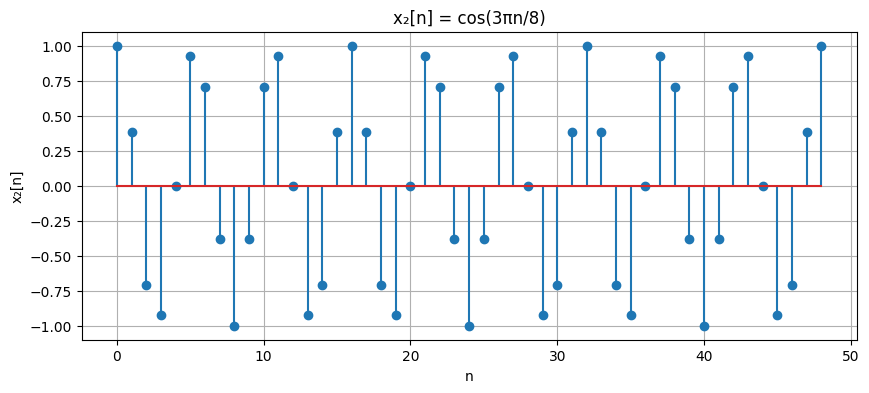

In [6]:
n = np.arange(0, 49)

x2 = np.cos(3 * np.pi * n / 8)

plt.figure(figsize=(10, 4))
plt.stem(n, x2)

plt.xlabel('n')
plt.ylabel('x₂[n]')
plt.title('x₂[n] = cos(3πn/8)')
plt.grid()

plt.show()

### c) Terceiro sinal

$$
x_3[n] = \sin(3n)
$$

Nesse caso:

$$
\Omega = 3
$$

Para que o sinal fosse periódico, seria necessário:

$$
\frac{\Omega}{2\pi}
=
\frac{3}{2\pi}
=
\frac{m}{N}
$$

Entretanto, como $\pi$ é irracional, $\frac{3}{2\pi}$ também é irracional e não pode ser representado como uma razão entre dois números inteiros.

Portanto, não existe um período inteiro $N$ que satisfaça:

$$
x[n+N] = x[n]
$$

Logo, o sinal não é periódico:

$$
\boxed{x_3[n]\text{ não é periódico}}
$$

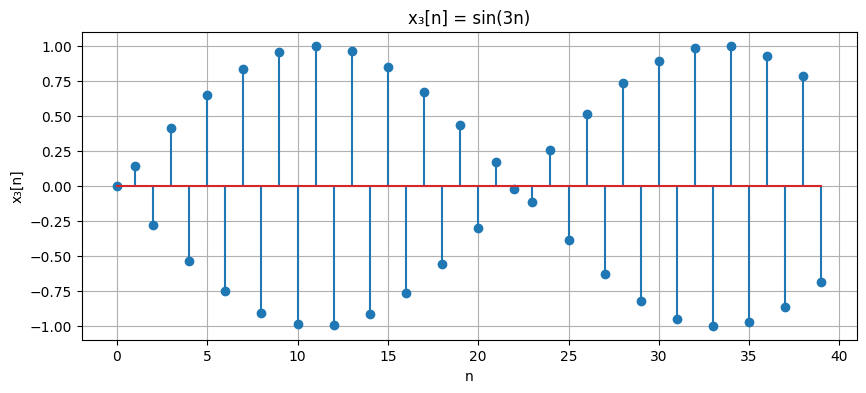

In [7]:
n = np.arange(0, 40)

x3 = np.sin(3 * n)

plt.figure(figsize=(10, 4))
plt.stem(n, x3)

plt.xlabel('n')
plt.ylabel('x₃[n]')
plt.title('x₃[n] = sin(3n)')
plt.grid()

plt.show()